# NYC Taxi Spatio-Temporal Demand Modeling

This notebook focuses on demand-side modeling for NYC yellow taxi pickups. The main workflow is:

1. Data preprocessing
2. Demand characterization
3. Zone-time panel construction
4. Stochastic demand modeling: Poisson/NHPP -> overdispersion diagnosis -> Negative Binomial extension
5. Machine learning forecasting and quantile uncertainty estimation
6. Spatial lag features and temporal vs spatio-temporal comparison



## Part 0. Data Preprocessing


In [10]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None


In [11]:
# Data import and initial preprocessing

DATA_PATH = "C:/Users/ZZKT1/Desktop/LIAR/NYC Taxi trip Project/yellow_tripdata_2026-01.parquet"

df = pd.read_parquet(DATA_PATH)

df = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["PULocationID"].notna())
].copy()

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["hour"] = df["tpep_pickup_datetime"].dt.hour
df["day"] = df["tpep_pickup_datetime"].dt.day
df["weekday"] = df["tpep_pickup_datetime"].dt.weekday

print(df.shape)
display(df.head())


(3560862, 23)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,hour,day,weekday
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,3.66,0.0,1.0,15.86,2.5,0.0,0.00,0,1,3
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,0.00,0.0,1.0,13.65,2.5,0.0,0.75,0,1,3
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,2.50,0.0,1.0,18.95,2.5,0.0,0.75,0,1,3
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,11.11,0.0,1.0,55.56,2.5,0.0,0.75,0,1,3
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,3.85,0.0,1.0,23.10,2.5,0.0,0.75,0,1,3


In [12]:
# Total pickups by pickup zone

pickup_counts = (
    df.groupby("PULocationID")
      .size()
      .reset_index(name="pickup_count")
)

pickup_counts["PULocationID"] = pickup_counts["PULocationID"].astype(int)
display(pickup_counts.head())


,PULocationID,pickup_count
0,1,117
1,2,3
2,3,470
3,4,15629
4,5,3


In [13]:
# Load taxi zones and merge total pickup counts

ZONES_PATH = "C:/Users/ZZKT1/Desktop/LIAR/NYC Taxi trip Project/taxi_zones/taxi_zones/taxi_zones.shp"

zones_raw = gpd.read_file(ZONES_PATH)
zones_raw["LocationID"] = zones_raw["LocationID"].astype(int)

zones = zones_raw.merge(
    pickup_counts,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

zones["pickup_count"] = zones["pickup_count"].fillna(0)

display(zones.head())


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,pickup_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,117.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,3.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,470.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,15629.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,3.0


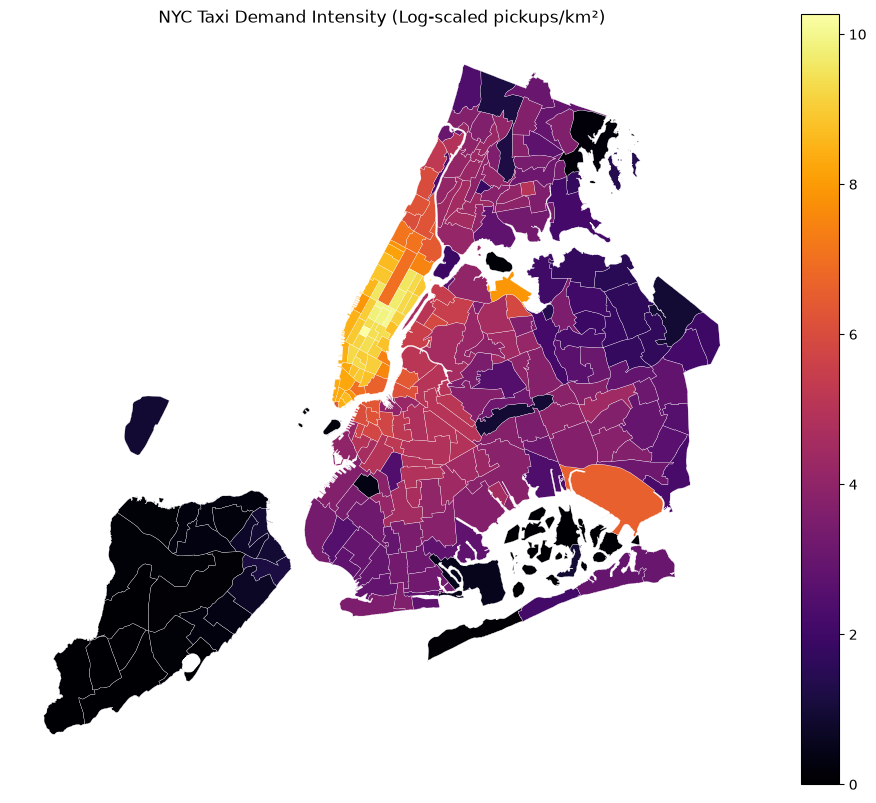

In [14]:
# Demand intensity map

zones = zones.to_crs(epsg=2263)
zones["area"] = zones.geometry.area
zones["area_km2"] = zones["area"] / 10**6
zones["intensity"] = zones["pickup_count"] / zones["area_km2"]
zones["log_intensity"] = np.log1p(zones["intensity"])

# Base spatial layer reused by all later spatio-temporal maps.
zones_base = zones.copy()
zones_base["LocationID"] = zones_base["LocationID"].astype(int)

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones.plot(
    column="log_intensity",
    cmap="inferno",
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

ax.set_title("NYC Taxi Demand Intensity (Log-scaled pickups/km²)", fontsize=12)
ax.set_axis_off()

plt.show()


## Part 1. Demand Characterization

This section describes spatial concentration, temporal periodicity, zone-hour patterns, demand intensity, and zone-level heterogeneity.


In [15]:
# Temporal preprocessing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

df = df.copy()

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

# Keep January 2026 records with valid pickup zones.
df = df[
    (df["tpep_pickup_datetime"] >= "2026-01-01") &
    (df["tpep_pickup_datetime"] < "2026-02-01") &
    (df["PULocationID"].notna())
].copy()

df["PULocationID"] = df["PULocationID"].astype(int)
df["DOLocationID"] = df["DOLocationID"].astype("Int64")

df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df = df[
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["trip_duration_min"].between(1, 240))
].copy()

# Change this to "15min" if you want finer temporal resolution.
TIME_FREQ = "30min"

df["time_bin"] = df["tpep_pickup_datetime"].dt.floor(TIME_FREQ)
df["dropoff_time_bin"] = df["tpep_dropoff_datetime"].dt.floor(TIME_FREQ)

df["hour"] = df["time_bin"].dt.hour
df["date"] = df["time_bin"].dt.date
df["weekday"] = df["time_bin"].dt.dayofweek
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

print(df.shape)
df[["tpep_pickup_datetime", "time_bin", "PULocationID", "DOLocationID", "trip_distance", "trip_duration_min"]].head()


(3504978, 28)


,tpep_pickup_datetime,time_bin,PULocationID,DOLocationID,trip_distance,trip_duration_min
0,2026-01-01 00:54:04,2026-01-01 00:30:00,239,238,0.97,5.550000
1,2026-01-01 00:34:04,2026-01-01 00:30:00,163,162,0.90,5.716667
2,2026-01-01 00:57:06,2026-01-01 00:30:00,43,237,1.40,8.883333
3,2026-01-01 00:15:22,2026-01-01 00:00:00,142,209,5.58,42.800000
4,2026-01-01 00:27:13,2026-01-01 00:00:00,88,144,2.16,13.500000


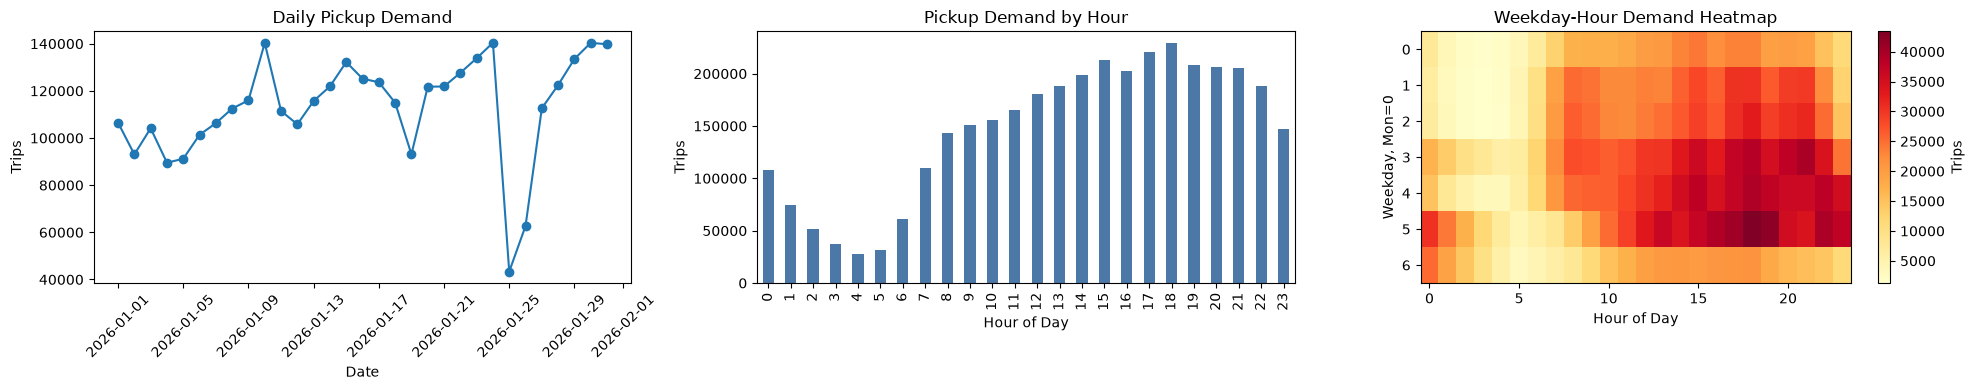

In [16]:
# Overall temporal demand patterns

daily_demand = df.groupby(df["time_bin"].dt.date).size()
hourly_demand = df.groupby("hour").size()
weekday_hour = (
    df.groupby(["weekday", "hour"])
      .size()
      .reset_index(name="pickup_count")
      .pivot(index="weekday", columns="hour", values="pickup_count")
      .fillna(0)
)

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

daily_demand.plot(ax=axes[0], marker="o", linewidth=1.5)
axes[0].set_title("Daily Pickup Demand")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Trips")
axes[0].tick_params(axis="x", rotation=45)

hourly_demand.reindex(range(24), fill_value=0).plot(kind="bar", ax=axes[1], color="#4C78A8")
axes[1].set_title("Pickup Demand by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Trips")

if sns is not None:
    sns.heatmap(
        weekday_hour.reindex(index=range(7), columns=range(24), fill_value=0),
        cmap="YlOrRd",
        ax=axes[2],
        cbar_kws={"label": "Trips"}
    )
else:
    im = axes[2].imshow(weekday_hour.reindex(index=range(7), columns=range(24), fill_value=0), aspect="auto", cmap="YlOrRd")
    fig.colorbar(im, ax=axes[2], label="Trips")

axes[2].set_title("Weekday-Hour Demand Heatmap")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Weekday, Mon=0")

plt.tight_layout()
plt.show()


## Part 2. Zone-Time Panel and Forecasting Target

The project uses a common zone-time grid:

`Y_{z,t} = pickup_count`

The modeling target is next-interval demand:

`Y_{z,t+1} = target_next_pickup_count`.


## Build a zone-time demand panel

Each row below is one taxi zone in one time interval. This panel is the central dataset for spatio-temporal forecasting and later taxi allocation.


In [17]:
# Pickup demand by zone-time

all_zones = sorted(df["PULocationID"].dropna().astype(int).unique())
all_times = pd.date_range(
    df["time_bin"].min(),
    df["time_bin"].max(),
    freq=TIME_FREQ
)

full_index = pd.MultiIndex.from_product(
    [all_zones, all_times],
    names=["PULocationID", "time_bin"]
)

pickup_panel = (
    df.groupby(["PULocationID", "time_bin"])
      .size()
      .rename("pickup_count")
      .reindex(full_index, fill_value=0)
      .reset_index()
)

# Dropoffs are a useful proxy for local taxi supply becoming available.
dropoff_panel = (
    df.dropna(subset=["DOLocationID", "dropoff_time_bin"])
      .assign(DOLocationID=lambda x: x["DOLocationID"].astype(int))
      .groupby(["DOLocationID", "dropoff_time_bin"])
      .size()
      .rename("dropoff_count")
      .reset_index()
      .rename(columns={"DOLocationID": "PULocationID", "dropoff_time_bin": "time_bin"})
)

# Aggregate trip attributes by pickup zone-time.
trip_attr_panel = (
    df.groupby(["PULocationID", "time_bin"])
      .agg(
          mean_trip_distance=("trip_distance", "mean"),
          mean_trip_duration_min=("trip_duration_min", "mean"),
          mean_total_amount=("total_amount", "mean"),
          mean_passenger_count=("passenger_count", "mean")
      )
      .reset_index()
)

demand_panel = (
    pickup_panel
    .merge(dropoff_panel, on=["PULocationID", "time_bin"], how="left")
    .merge(trip_attr_panel, on=["PULocationID", "time_bin"], how="left")
)

demand_panel["dropoff_count"] = demand_panel["dropoff_count"].fillna(0)

for col in ["mean_trip_distance", "mean_trip_duration_min", "mean_total_amount", "mean_passenger_count"]:
    demand_panel[col] = demand_panel[col].fillna(0)

demand_panel["hour"] = demand_panel["time_bin"].dt.hour
demand_panel["weekday"] = demand_panel["time_bin"].dt.dayofweek
demand_panel["is_weekend"] = demand_panel["weekday"].isin([5, 6]).astype(int)
demand_panel["date"] = demand_panel["time_bin"].dt.date

print(demand_panel.shape)
demand_panel.head()


(388368, 12)


,PULocationID,time_bin,pickup_count,dropoff_count,mean_trip_distance,mean_trip_duration_min,mean_total_amount,mean_passenger_count,hour,weekday,is_weekend,date
0,1,2026-01-01 00:00:00,0,0.0,0.0,0.0,0.0,0.0,0,3,0,2026-01-01
1,1,2026-01-01 00:30:00,0,0.0,0.0,0.0,0.0,0.0,0,3,0,2026-01-01
2,1,2026-01-01 01:00:00,0,1.0,0.0,0.0,0.0,0.0,1,3,0,2026-01-01
3,1,2026-01-01 01:30:00,0,0.0,0.0,0.0,0.0,0.0,1,3,0,2026-01-01
4,1,2026-01-01 02:00:00,0,0.0,0.0,0.0,0.0,0.0,2,3,0,2026-01-01


In [18]:
# Temporal feature engineering for forecasting

demand_panel = demand_panel.sort_values(["PULocationID", "time_bin"]).copy()

grouped = demand_panel.groupby("PULocationID", group_keys=False)

for lag in [1, 2, 4, 8, 48]:
    demand_panel[f"pickup_lag_{lag}"] = grouped["pickup_count"].shift(lag)
    demand_panel[f"dropoff_lag_{lag}"] = grouped["dropoff_count"].shift(lag)

demand_panel["rolling_mean_2h"] = grouped["pickup_count"].transform(
    lambda s: s.shift(1).rolling(4, min_periods=1).mean()
)
demand_panel["rolling_std_2h"] = grouped["pickup_count"].transform(
    lambda s: s.shift(1).rolling(4, min_periods=2).std()
)
demand_panel["rolling_mean_6h"] = grouped["pickup_count"].transform(
    lambda s: s.shift(1).rolling(12, min_periods=1).mean()
)
demand_panel["previous_day_same_time"] = grouped["pickup_count"].shift(48)

# Forecast target: demand in the next time interval.
demand_panel["target_next_pickup_count"] = grouped["pickup_count"].shift(-1)

model_panel = demand_panel.dropna(subset=[
    "pickup_lag_1",
    "pickup_lag_2",
    "pickup_lag_4",
    "pickup_lag_48",
    "target_next_pickup_count"
]).copy()

model_panel["rolling_std_2h"] = model_panel["rolling_std_2h"].fillna(0)

print(model_panel.shape)
model_panel.head()


(375579, 27)


,PULocationID,time_bin,pickup_count,dropoff_count,mean_trip_distance,mean_trip_duration_min,mean_total_amount,mean_passenger_count,hour,weekday,...,dropoff_lag_4,pickup_lag_8,dropoff_lag_8,pickup_lag_48,dropoff_lag_48,rolling_mean_2h,rolling_std_2h,rolling_mean_6h,previous_day_same_time,target_next_pickup_count
48,1,2026-01-02 00:00:00,0,2.0,0.0,0.0,0.0,0.0,0,4,...,0.0,0.0,1.0,0.0,0.0,0.50,0.57735,0.25,0.0,0.0
49,1,2026-01-02 00:30:00,0,0.0,0.0,0.0,0.0,0.0,0,4,...,0.0,0.0,1.0,0.0,0.0,0.50,0.57735,0.25,0.0,0.0
50,1,2026-01-02 01:00:00,0,0.0,0.0,0.0,0.0,0.0,1,4,...,0.0,1.0,0.0,0.0,1.0,0.25,0.50000,0.25,0.0,0.0
51,1,2026-01-02 01:30:00,0,0.0,0.0,0.0,0.0,0.0,1,4,...,0.0,0.0,0.0,0.0,0.0,0.25,0.50000,0.25,0.0,0.0
52,1,2026-01-02 02:00:00,0,0.0,0.0,0.0,0.0,0.0,2,4,...,2.0,0.0,0.0,0.0,0.0,0.00,0.00000,0.25,0.0,0.0


### Panel-Based Demand Characterization

The following spatio-temporal visualizations and heterogeneity diagnostics require `demand_panel`, so they are placed after the zone-time panel is constructed.


## Spatio-temporal demand visualization

The next plots show how demand changes across both time and space.


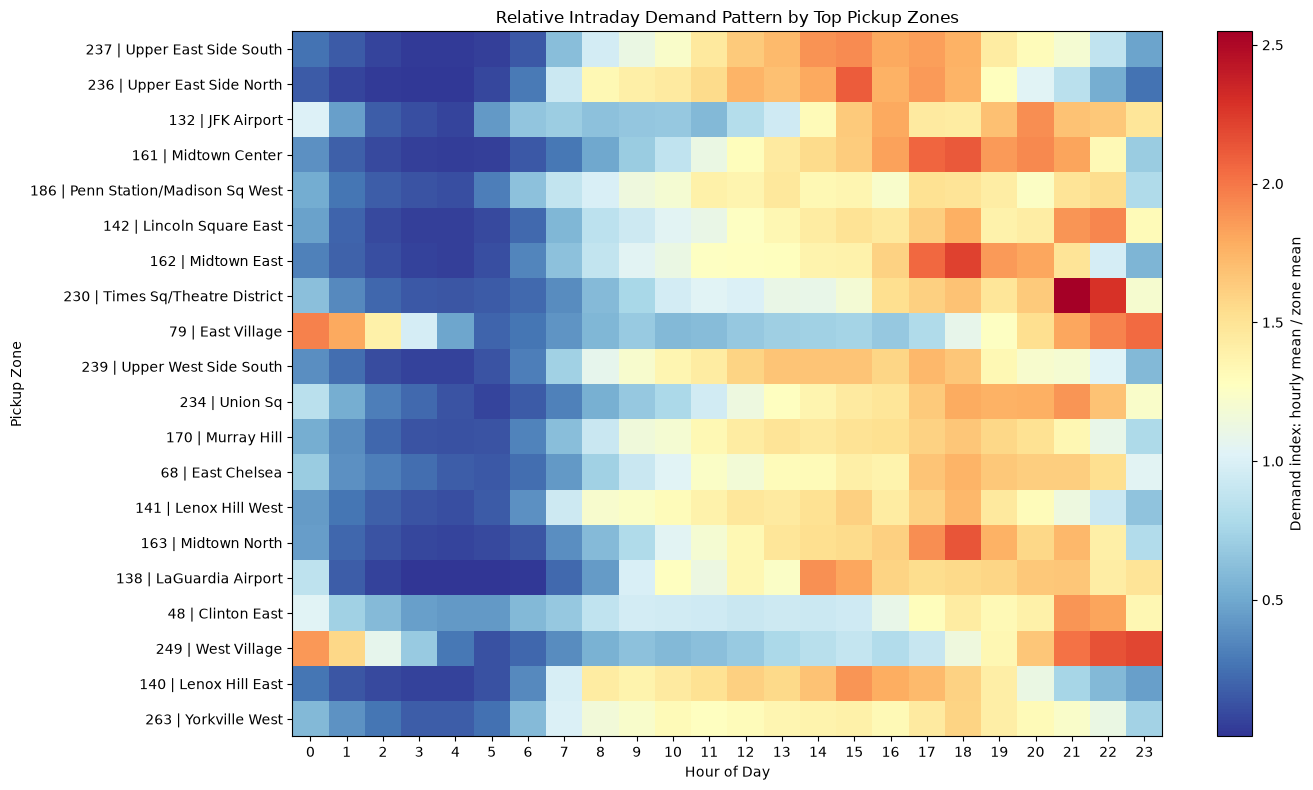

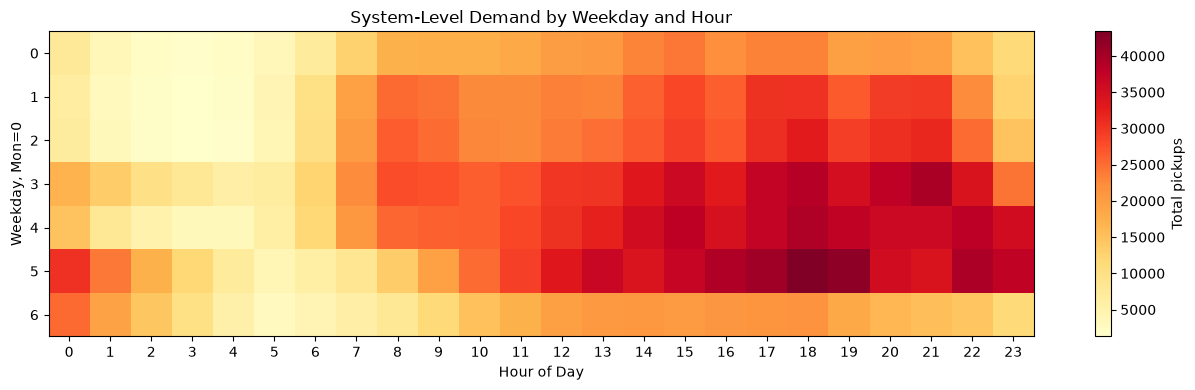

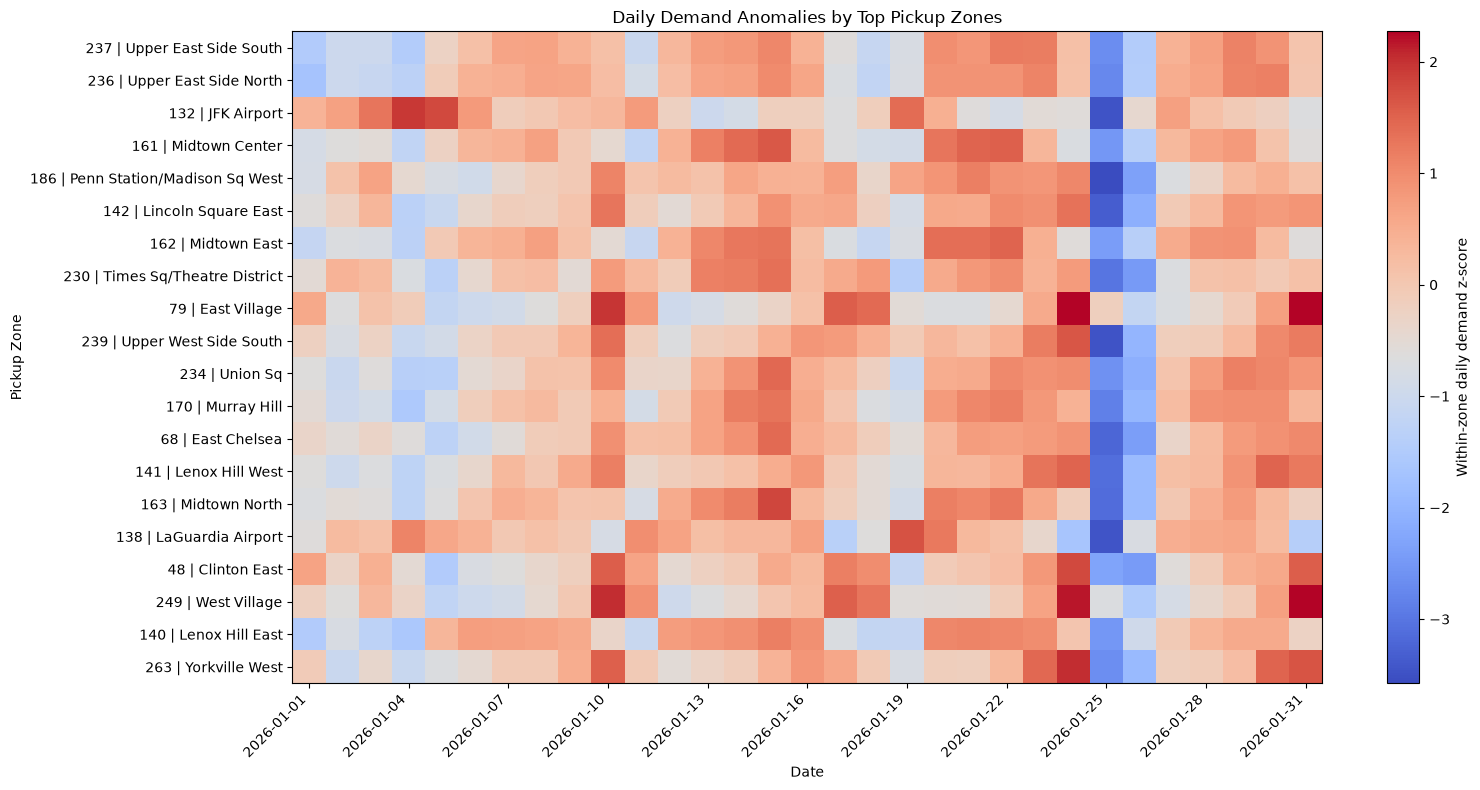

In [19]:
# Better spatio-temporal visualizations
#
# These views compress time into interpretable structures and normalize within each zone.

required_objects = ["demand_panel", "zones_base"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise RuntimeError(
        "Please run the earlier preprocessing and spatial cells first. "
        "This section requires demand_panel and zones_base."
    )

top_n = 20
top_zones = (
    demand_panel.groupby("PULocationID")["pickup_count"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

zone_labels = (
    zones_base[["LocationID", "zone", "borough"]]
    .drop_duplicates()
    .assign(LocationID=lambda x: x["LocationID"].astype(int))
)

top_zone_labels = (
    pd.DataFrame({"PULocationID": top_zones})
    .merge(zone_labels, left_on="PULocationID", right_on="LocationID", how="left")
)
top_zone_labels["zone_label"] = (
    top_zone_labels["PULocationID"].astype(str)
    + " | "
    + top_zone_labels["zone"].fillna("Unknown")
)

plot_panel = demand_panel[demand_panel["PULocationID"].isin(top_zones)].copy()
plot_panel = plot_panel.merge(
    top_zone_labels[["PULocationID", "zone_label"]],
    on="PULocationID",
    how="left"
)

# 1) Average intraday pattern by zone.
zone_hour = (
    plot_panel.groupby(["zone_label", "hour"])["pickup_count"]
    .mean()
    .reset_index()
)

zone_hour_pivot = (
    zone_hour.pivot(index="zone_label", columns="hour", values="pickup_count")
    .reindex(top_zone_labels["zone_label"])
    .fillna(0)
)

zone_hour_index = zone_hour_pivot.div(zone_hour_pivot.mean(axis=1).replace(0, np.nan), axis=0)

plt.figure(figsize=(14, 8))
if sns is not None:
    sns.heatmap(
        zone_hour_index,
        cmap="RdYlBu_r",
        center=1,
        cbar_kws={"label": "Demand index: hourly mean / zone mean"}
    )
else:
    plt.imshow(zone_hour_index.to_numpy(), aspect="auto", cmap="RdYlBu_r")
    plt.yticks(range(len(zone_hour_index.index)), zone_hour_index.index)
    plt.xticks(range(len(zone_hour_index.columns)), zone_hour_index.columns)
    plt.colorbar(label="Demand index: hourly mean / zone mean")

plt.title("Relative Intraday Demand Pattern by Top Pickup Zones")
plt.xlabel("Hour of Day")
plt.ylabel("Pickup Zone")
plt.tight_layout()
plt.show()


# 2) Weekday-hour pattern for the whole system.
weekday_hour = (
    demand_panel.groupby(["weekday", "hour"])["pickup_count"]
    .sum()
    .reset_index()
    .pivot(index="weekday", columns="hour", values="pickup_count")
    .reindex(index=range(7), columns=range(24), fill_value=0)
)

plt.figure(figsize=(13, 4))
if sns is not None:
    sns.heatmap(
        weekday_hour,
        cmap="YlOrRd",
        cbar_kws={"label": "Total pickups"}
    )
else:
    plt.imshow(weekday_hour.to_numpy(), aspect="auto", cmap="YlOrRd")
    plt.yticks(range(len(weekday_hour.index)), weekday_hour.index)
    plt.xticks(range(len(weekday_hour.columns)), weekday_hour.columns)
    plt.colorbar(label="Total pickups")

plt.title("System-Level Demand by Weekday and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday, Mon=0")
plt.tight_layout()
plt.show()


# 3) Daily anomaly pattern by zone.
zone_day = (
    plot_panel.groupby(["zone_label", "date"])["pickup_count"]
    .sum()
    .reset_index()
)

zone_day_pivot = (
    zone_day.pivot(index="zone_label", columns="date", values="pickup_count")
    .reindex(top_zone_labels["zone_label"])
    .fillna(0)
)

zone_day_z = zone_day_pivot.sub(zone_day_pivot.mean(axis=1), axis=0)
zone_day_z = zone_day_z.div(zone_day_pivot.std(axis=1).replace(0, np.nan), axis=0).fillna(0)

plt.figure(figsize=(16, 8))
if sns is not None:
    sns.heatmap(
        zone_day_z,
        cmap="vlag",
        center=0,
        cbar_kws={"label": "Within-zone daily demand z-score"}
    )
else:
    plt.imshow(zone_day_z.to_numpy(), aspect="auto", cmap="coolwarm")
    plt.yticks(range(len(zone_day_z.index)), zone_day_z.index)
    date_labels = [str(x) for x in zone_day_z.columns]
    tick_step = max(len(date_labels) // 10, 1)
    tick_positions = list(range(0, len(date_labels), tick_step))
    plt.xticks(tick_positions, [date_labels[i] for i in tick_positions], rotation=45, ha="right")
    plt.colorbar(label="Within-zone daily demand z-score")

plt.title("Daily Demand Anomalies by Top Pickup Zones")
plt.xlabel("Date")
plt.ylabel("Pickup Zone")
plt.tight_layout()
plt.show()


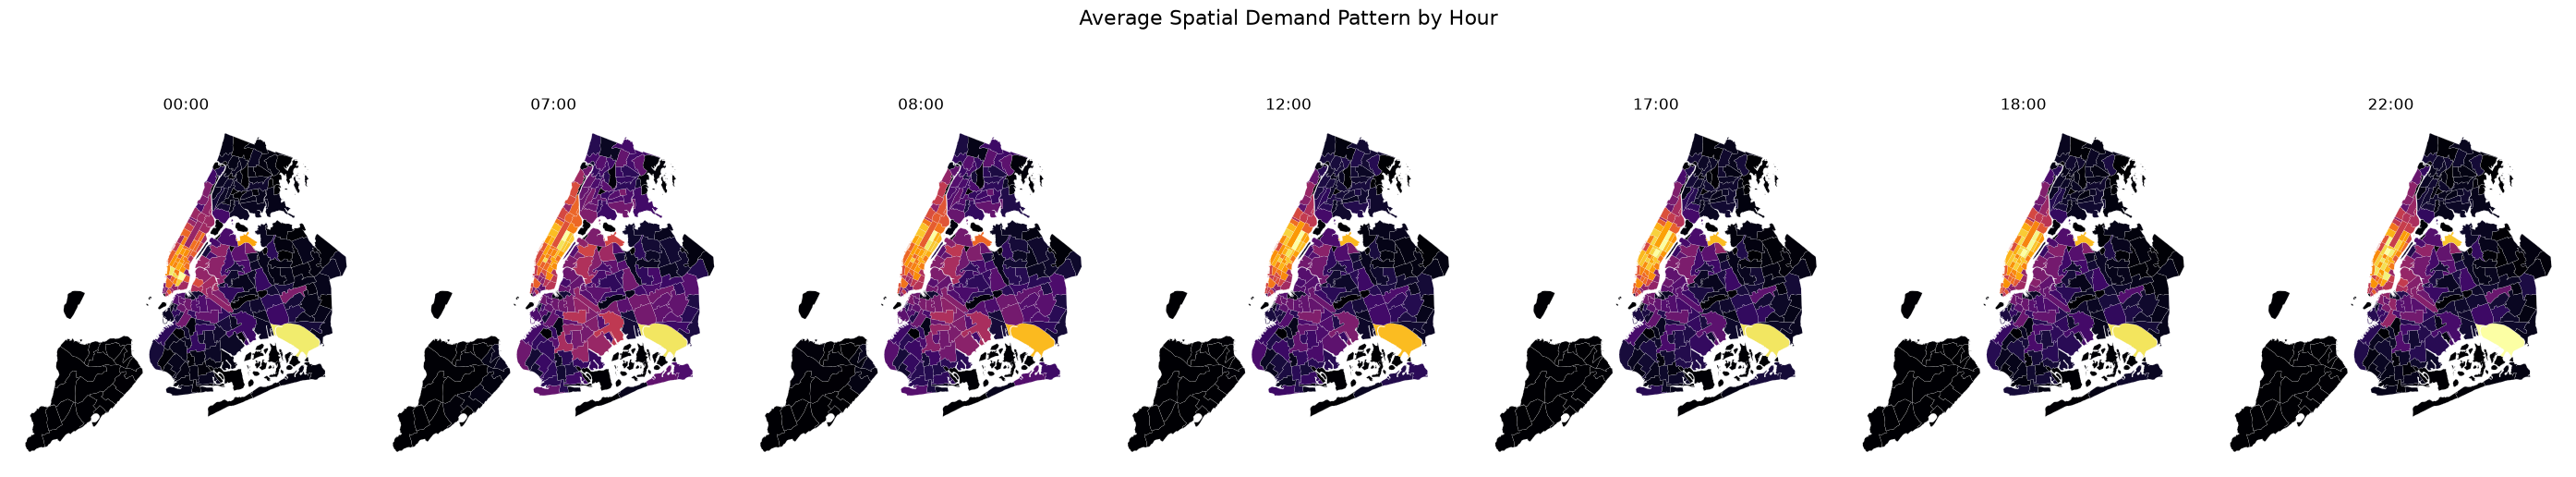

In [20]:
# Small-multiple maps: average demand intensity by hour of day

required_objects = ["demand_panel", "zones_base"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise RuntimeError(
        "Please run the earlier preprocessing and spatial cells first. "
        "This section requires demand_panel and zones_base."
    )

hour_zone = (
    demand_panel.groupby(["PULocationID", "hour"])["pickup_count"]
    .mean()
    .reset_index(name="avg_pickups_per_bin")
)

selected_hours = [0, 7, 8, 12, 17, 18, 22]

fig, axes = plt.subplots(1, len(selected_hours), figsize=(4 * len(selected_hours), 6))

for ax, h in zip(axes, selected_hours):
    plot_df = zones_base.merge(
        hour_zone[hour_zone["hour"] == h],
        left_on="LocationID",
        right_on="PULocationID",
        how="left"
    )
    plot_df["avg_pickups_per_bin"] = plot_df["avg_pickups_per_bin"].fillna(0)
    plot_df["log_avg_pickups"] = np.log1p(plot_df["avg_pickups_per_bin"])
    
    plot_df.plot(
        column="log_avg_pickups",
        cmap="inferno",
        edgecolor="white",
        linewidth=0.1,
        ax=ax,
        legend=False
    )
    ax.set_title(f"{h:02d}:00")
    ax.set_axis_off()

fig.suptitle("Average Spatial Demand Pattern by Hour", fontsize=16)
plt.tight_layout()
plt.show()


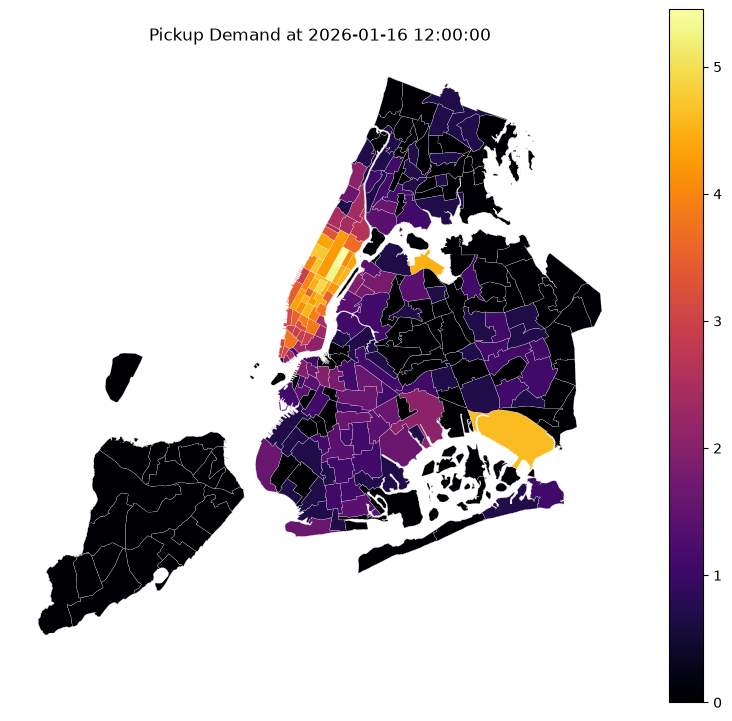

In [21]:
# Function for mapping any chosen time bin

def plot_zone_demand_at_time(time_value, panel=None, zones_gdf=None):
    if panel is None:
        if "demand_panel" not in globals():
            raise RuntimeError("demand_panel is not defined. Run the zone-time panel cells first.")
        panel = demand_panel
    
    if zones_gdf is None:
        if "zones_base" not in globals():
            raise RuntimeError("zones_base is not defined. Run the spatial base layer cells first.")
        zones_gdf = zones_base
    
    time_value = pd.Timestamp(time_value)
    
    one_time = (
        panel.loc[panel["time_bin"] == time_value, ["PULocationID", "pickup_count"]]
        .copy()
    )
    one_time["PULocationID"] = one_time["PULocationID"].astype(int)
    
    stale_cols = [
        col for col in zones_gdf.columns
        if col.startswith("pickup_count") or col.startswith("log_pickup_count")
    ]
    clean_zones = zones_gdf.drop(columns=stale_cols, errors="ignore").copy()
    clean_zones["LocationID"] = clean_zones["LocationID"].astype(int)
    
    plot_df = clean_zones.merge(
        one_time,
        left_on="LocationID",
        right_on="PULocationID",
        how="left",
        validate="one_to_one"
    )
    
    plot_df["pickup_count"] = plot_df["pickup_count"].fillna(0)
    plot_df["log_pickup_count"] = np.log1p(plot_df["pickup_count"])
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 9))
    plot_df.plot(
        column="log_pickup_count",
        cmap="inferno",
        legend=True,
        edgecolor="white",
        linewidth=0.15,
        ax=ax,
        missing_kwds={"color": "lightgrey"}
    )
    ax.set_title(f"Pickup Demand at {time_value}")
    ax.set_axis_off()
    plt.show()


available_times = demand_panel["time_bin"].drop_duplicates().sort_values()
example_time = available_times.iloc[len(available_times) // 2]
plot_zone_demand_at_time(example_time)


### Demand Heterogeneity

This diagnostic summarizes how uneven demand is across taxi zones, including total demand, average demand, demand variability, and zero-demand share.


,PULocationID,total_pickups,mean_pickups_per_bin,std_pickups_per_bin,max_pickups_per_bin,zero_demand_share,cv_pickups,LocationID,zone,borough
232,237,152253,102.320565,82.466647,285,0.014785,0.805964,237.0,Upper East Side South,Manhattan
231,236,145419,97.727823,81.797932,320,0.028226,0.836997,236.0,Upper East Side North,Manhattan
127,132,139941,94.046371,64.094499,292,0.014785,0.681520,132.0,JFK Airport,Queens
156,161,138939,93.372984,83.761534,390,0.008065,0.897064,161.0,Midtown Center,Manhattan
181,186,105463,70.875672,48.243150,312,0.003360,0.680673,186.0,Penn Station/Madison Sq West,Manhattan
137,142,104490,70.221774,56.380247,348,0.009409,0.802888,142.0,Lincoln Square East,Manhattan
157,162,103475,69.539651,57.569616,281,0.009409,0.827867,162.0,Midtown East,Manhattan
225,230,100546,67.571237,54.104860,366,0.002688,0.800708,230.0,Times Sq/Theatre District,Manhattan
78,79,96174,64.633065,69.321719,412,0.000000,1.072543,79.0,East Village,Manhattan
234,239,92229,61.981855,43.959116,199,0.019489,0.709226,239.0,Upper West Side South,Manhattan


,PULocationID,total_pickups,mean_pickups_per_bin,std_pickups_per_bin,max_pickups_per_bin,zero_demand_share,cv_pickups,LocationID,zone,borough
43,44,1,0.000672,0.025924,1,0.999328,38.574603,44.0,Charleston/Tottenville,Staten Island
199,204,1,0.000672,0.025924,1,0.999328,38.574603,204.0,Rossville/Woodrow,Staten Island
101,105,2,0.001344,0.036649,1,0.998656,27.267190,105.0,Governor's Island/Ellis Island/Liberty Island,Manhattan
83,84,2,0.001344,0.036649,1,0.998656,27.267190,84.0,Eltingville/Annadale/Prince's Bay,Staten Island
4,5,2,0.001344,0.036649,1,0.998656,27.267190,5.0,Arden Heights,Staten Island
1,2,3,0.002016,0.044871,1,0.997984,22.256075,2.0,Jamaica Bay,Queens
194,199,3,0.002016,0.044871,1,0.997984,22.256075,199.0,Rikers Island,Bronx
182,187,10,0.006720,0.096797,2,0.994624,14.403452,187.0,Port Richmond,Staten Island
26,27,8,0.005376,0.073151,1,0.994624,13.606043,27.0,Breezy Point/Fort Tilden/Riis Beach,Queens
106,111,9,0.006048,0.077562,1,0.993952,12.823566,111.0,Green-Wood Cemetery,Brooklyn


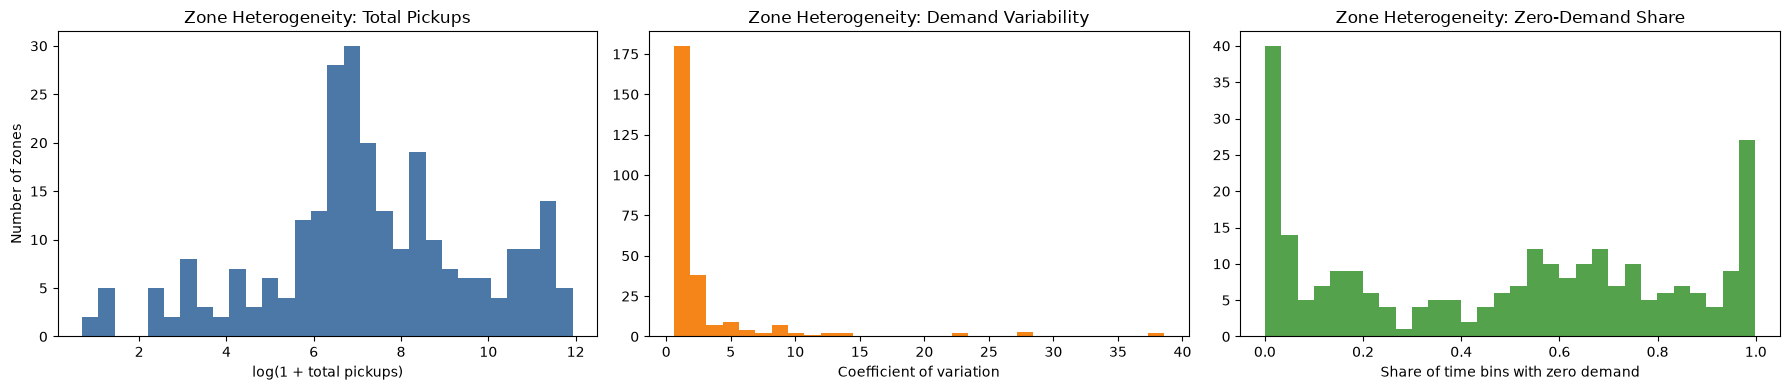

In [22]:
# Demand heterogeneity across zones

required_objects = ["demand_panel"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise RuntimeError(
        "Please run the earlier preprocessing cells first. "
        "This section requires demand_panel, which is created in "
        "'Build a zone-time demand panel' / 'Pickup demand by zone-time'."
    )

zone_summary = (
    demand_panel.groupby("PULocationID")
    .agg(
        total_pickups=("pickup_count", "sum"),
        mean_pickups_per_bin=("pickup_count", "mean"),
        std_pickups_per_bin=("pickup_count", "std"),
        max_pickups_per_bin=("pickup_count", "max"),
        zero_demand_share=("pickup_count", lambda s: (s == 0).mean()),
    )
    .reset_index()
)

zone_summary["cv_pickups"] = (
    zone_summary["std_pickups_per_bin"]
    / zone_summary["mean_pickups_per_bin"].replace(0, np.nan)
).fillna(0)

if "zones_base" in globals():
    zone_summary = zone_summary.merge(
        zones_base[["LocationID", "zone", "borough"]].drop_duplicates(),
        left_on="PULocationID",
        right_on="LocationID",
        how="left"
    )

display(zone_summary.sort_values("total_pickups", ascending=False).head(15))
display(zone_summary.sort_values("cv_pickups", ascending=False).head(15))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(np.log1p(zone_summary["total_pickups"]), bins=30, color="#4C78A8")
axes[0].set_title("Zone Heterogeneity: Total Pickups")
axes[0].set_xlabel("log(1 + total pickups)")
axes[0].set_ylabel("Number of zones")

axes[1].hist(zone_summary["cv_pickups"], bins=30, color="#F58518")
axes[1].set_title("Zone Heterogeneity: Demand Variability")
axes[1].set_xlabel("Coefficient of variation")

axes[2].hist(zone_summary["zero_demand_share"], bins=30, color="#54A24B")
axes[2].set_title("Zone Heterogeneity: Zero-Demand Share")
axes[2].set_xlabel("Share of time bins with zero demand")

plt.tight_layout()
plt.show()


## Part 3. Stochastic Demand Modeling Process

We first use a Poisson/NHPP count-process baseline. Then we test whether the Poisson variance assumption is reasonable. If overdispersion is present, we use a Negative Binomial extension.


### Model Definition

Let `z` index taxi zones and `t` index fixed time intervals.

`Y_{z,t}` is the number of pickups in zone `z` during interval `t`.

The forecasting target is next-interval demand:

`Y_{z,t+1} = target_next_pickup_count`.


In [23]:
# Add cyclic temporal features for stochastic models

for panel in [demand_panel, model_panel]:
    panel["hour_sin"] = np.sin(2 * np.pi * panel["hour"] / 24)
    panel["hour_cos"] = np.cos(2 * np.pi * panel["hour"] / 24)
    panel["weekday_sin"] = np.sin(2 * np.pi * panel["weekday"] / 7)
    panel["weekday_cos"] = np.cos(2 * np.pi * panel["weekday"] / 7)

stochastic_features = [
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "is_weekend",
    "pickup_lag_1",
    "pickup_lag_2",
    "pickup_lag_4",
    "pickup_lag_48",
    "dropoff_lag_1",
    "rolling_mean_2h",
    "rolling_std_2h",
    "previous_day_same_time",
]

stochastic_panel = model_panel.dropna(subset=stochastic_features + ["target_next_pickup_count"]).copy()

cutoff_time = stochastic_panel["time_bin"].quantile(0.8)
stoch_train = stochastic_panel[stochastic_panel["time_bin"] <= cutoff_time].copy()
stoch_test = stochastic_panel[stochastic_panel["time_bin"] > cutoff_time].copy()

print("Train shape:", stoch_train.shape)
print("Test shape:", stoch_test.shape)
print("Target:", "target_next_pickup_count")


Train shape: (300672, 31)
Test shape: (74907, 31)
Target: target_next_pickup_count


In [28]:
# 2.2 Poisson / NHPP baseline
#
# We use sklearn's PoissonRegressor instead of statsmodels GLM here.
# Reason: statsmodels formula C(PULocationID) creates a large dense design matrix,
# which can cause MemoryError on the full zone-time panel. sklearn keeps the
# zone one-hot encoding sparse inside the pipeline.

try:
    from sklearn.compose import ColumnTransformer
    from sklearn.linear_model import PoissonRegressor
    from sklearn.metrics import mean_poisson_deviance
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    
    def demand_metrics(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        return pd.Series({
            "MAE": np.mean(np.abs(y_true - y_pred)),
            "RMSE": np.sqrt(np.mean((y_true - y_pred) ** 2)),
            "sMAPE": np.mean(
                2 * np.abs(y_pred - y_true)
                / (np.abs(y_true) + np.abs(y_pred) + 1e-9)
            ),
        })
    
    poisson_numeric_features = [
        "hour_sin",
        "hour_cos",
        "weekday_sin",
        "weekday_cos",
        "is_weekend",
        "pickup_lag_1",
        "pickup_lag_2",
        "pickup_lag_4",
        "pickup_lag_48",
        "dropoff_lag_1",
        "rolling_mean_2h",
        "rolling_std_2h",
        "previous_day_same_time",
    ]
    poisson_categorical_features = ["PULocationID"]
    poisson_feature_cols = poisson_categorical_features + poisson_numeric_features
    
    poisson_train = stoch_train.dropna(
        subset=poisson_feature_cols + ["target_next_pickup_count"]
    ).copy()
    poisson_test = stoch_test.dropna(
        subset=poisson_feature_cols + ["target_next_pickup_count"]
    ).copy()
    
    try:
        zone_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        zone_encoder = OneHotEncoder(handle_unknown="ignore", sparse=True)
    
    poisson_preprocess = ColumnTransformer(
        transformers=[
            ("zone", zone_encoder, poisson_categorical_features),
            ("num", StandardScaler(), poisson_numeric_features),
        ],
        sparse_threshold=1.0,
    )
    
    poisson_sklearn_model = Pipeline(steps=[
        ("preprocess", poisson_preprocess),
        ("model", PoissonRegressor(alpha=1.0, max_iter=300)),
    ])
    
    poisson_sklearn_model.fit(
        poisson_train[poisson_feature_cols],
        poisson_train["target_next_pickup_count"],
    )
    
    poisson_test["poisson_mu"] = np.clip(
        poisson_sklearn_model.predict(poisson_test[poisson_feature_cols]),
        1e-9,
        None,
    )
    
    # Keep the original stoch_test object updated for later cells.
    stoch_test = stoch_test.drop(columns=["poisson_mu"], errors="ignore").merge(
        poisson_test[["PULocationID", "time_bin", "poisson_mu"]],
        on=["PULocationID", "time_bin"],
        how="left",
    )
    
    poisson_metrics = demand_metrics(
        poisson_test["target_next_pickup_count"],
        poisson_test["poisson_mu"],
    )
    poisson_metrics["Mean Poisson deviance"] = mean_poisson_deviance(
        poisson_test["target_next_pickup_count"],
        poisson_test["poisson_mu"],
    )
    
    display(pd.DataFrame({"Poisson/NHPP baseline": poisson_metrics}).T)
    print("Model: sklearn PoissonRegressor with sparse zone one-hot encoding")
    print(
        "Full-panel AIC is not reported for this sklearn model. "
        "Because the goal is forecasting and the model is fit with sparse encoding/regularization, "
        "we evaluate it using out-of-sample MAE, RMSE, sMAPE, and mean Poisson deviance."
    )

except ImportError:
    print("scikit-learn is not installed. Install it with: pip install scikit-learn")


,MAE,RMSE,sMAPE,Mean Poisson deviance
Poisson/NHPP baseline,8.066487,23.906096,1.339928,11.175832


Model: sklearn PoissonRegressor with sparse zone one-hot encoding
Full-panel AIC is not reported for this sklearn model. Because the goal is forecasting and the model is fit with sparse encoding/regularization, we evaluate it using out-of-sample MAE, RMSE, sMAPE, and mean Poisson deviance.


In [29]:
# 2.3 Overdispersion diagnosis for Poisson assumption

if "poisson_test" in globals() and "poisson_mu" in poisson_test.columns:
    y_obs = poisson_test["target_next_pickup_count"].to_numpy(dtype=float)
    mu_hat = np.clip(poisson_test["poisson_mu"].to_numpy(dtype=float), 1e-9, None)
    
    # Pearson dispersion based on out-of-sample Poisson predictions.
    pearson_chi2 = np.sum((y_obs - mu_hat) ** 2 / mu_hat)
    
    approx_num_params = (
        len(poisson_numeric_features)
        + poisson_train["PULocationID"].nunique()
    )
    residual_df = max(len(poisson_test) - approx_num_params, 1)
    dispersion_ratio = pearson_chi2 / residual_df
    
    y_train = poisson_train["target_next_pickup_count"]
    unconditional_mean = y_train.mean()
    unconditional_var = y_train.var()
    unconditional_var_mean_ratio = unconditional_var / unconditional_mean
    
    diagnosis = pd.DataFrame({
        "diagnostic": [
            "Out-of-sample Pearson chi2 / approx residual df",
            "Training unconditional variance / mean",
            "Training target mean",
            "Training target variance",
            "Approx number of parameters",
        ],
        "value": [
            dispersion_ratio,
            unconditional_var_mean_ratio,
            unconditional_mean,
            unconditional_var,
            approx_num_params,
        ],
    })
    
    display(diagnosis)
    
    if dispersion_ratio > 1.5:
        print("Poisson equidispersion assumption likely fails. Upgrade to Negative Binomial or quantile uncertainty model.")
    else:
        print("Poisson equidispersion assumption is not strongly violated by this diagnostic.")
else:
    print("Run the Poisson/NHPP baseline cell first.")


,diagnostic,value
0,Out-of-sample Pearson chi2 / approx residual df,13.444454
1,Training unconditional variance / mean,74.010659
2,Training target mean,8.934899
3,Training target variance,661.277774
4,Approx number of parameters,274.000000


Poisson equidispersion assumption likely fails. Upgrade to Negative Binomial or quantile uncertainty model.


In [30]:
# 2.4 Negative Binomial extension if Poisson variance assumption fails
#
# Negative Binomial is fit with statsmodels on the busiest zones only.
# This keeps the statistical interpretation of NB while avoiding the dense
# full-panel design matrix that caused the Poisson MemoryError.

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    
    nb_top_n = 40
    nb_top_zones = (
        stoch_train.groupby("PULocationID")["target_next_pickup_count"]
        .sum()
        .sort_values(ascending=False)
        .head(nb_top_n)
        .index
    )
    
    nb_train_small = stoch_train[stoch_train["PULocationID"].isin(nb_top_zones)].copy()
    nb_test_small = stoch_test[stoch_test["PULocationID"].isin(nb_top_zones)].copy()
    
    nb_formula = (
        "target_next_pickup_count ~ C(PULocationID) "
        "+ hour_sin + hour_cos + weekday_sin + weekday_cos + is_weekend "
        "+ pickup_lag_1 + pickup_lag_2 + pickup_lag_4 + pickup_lag_48 "
        "+ dropoff_lag_1 + rolling_mean_2h + rolling_std_2h + previous_day_same_time"
    )
    
    y_train_nb = nb_train_small["target_next_pickup_count"]
    alpha_mom = max(
        (y_train_nb.var() - y_train_nb.mean()) / (y_train_nb.mean() ** 2 + 1e-9),
        1e-6,
    )
    
    nb_st_model = smf.glm(
        formula=nb_formula,
        data=nb_train_small,
        family=sm.families.NegativeBinomial(alpha=alpha_mom),
    ).fit()
    
    nb_test_small["nb_mu"] = np.clip(nb_st_model.predict(nb_test_small), 0, None)
    
    # Compare against the sklearn Poisson predictions on the same top-zone test subset.
    if "poisson_sklearn_model" in globals():
        nb_test_small["poisson_mu"] = np.clip(
            poisson_sklearn_model.predict(nb_test_small[poisson_feature_cols]),
            0,
            None,
        )
    
    comparison_cols = {
        "Poisson/NHPP on top zones": demand_metrics(
            nb_test_small["target_next_pickup_count"],
            nb_test_small["poisson_mu"],
        ),
        "Negative Binomial on top zones": demand_metrics(
            nb_test_small["target_next_pickup_count"],
            nb_test_small["nb_mu"],
        ),
    }
    
    model_comparison = pd.DataFrame(comparison_cols).T
    
    display(model_comparison)
    print("Top zones used for NB:", nb_top_n)
    print("Estimated NB alpha by method of moments:", alpha_mom)
    print("Negative Binomial AIC on top zones:", nb_st_model.aic)

except Exception as e:
    print("Negative Binomial extension skipped:", e)


,MAE,RMSE,sMAPE
Poisson/NHPP on top zones,31.436443,60.036825,0.822989
Negative Binomial on top zones,24.899955,89.731777,0.484426


Top zones used for NB: 40
Estimated NB alpha by method of moments: 0.9358083693786251
Negative Binomial AIC on top zones: 414300.24713351735


## Part 4. Predictive Forecasting and Demand Uncertainty

The ML model is the predictive layer of the project. It uses temporal, lag, rolling, zone, and trip-attribute features to forecast next-interval demand. Quantile models estimate demand uncertainty.


## Machine learning demand forecasting

This model uses temporal, spatial, lag, rolling, dropoff, and trip-attribute features to predict next-interval demand. If `scikit-learn` is available, the cell fits a tree-based forecasting model.


{'MAE': 2.3426056138441758, 'RMSE': np.float64(6.3681344311162835)}


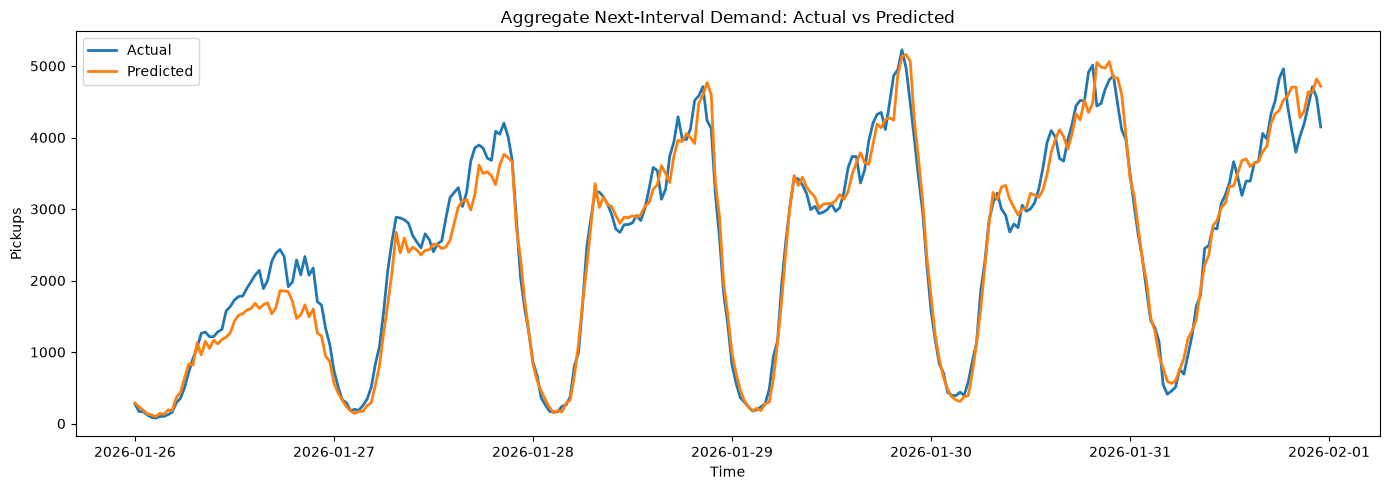

In [31]:
# ML forecasting model

feature_cols = [
    "PULocationID",
    "hour",
    "weekday",
    "is_weekend",
    "pickup_lag_1",
    "pickup_lag_2",
    "pickup_lag_4",
    "pickup_lag_8",
    "pickup_lag_48",
    "dropoff_count",
    "dropoff_lag_1",
    "dropoff_lag_2",
    "rolling_mean_2h",
    "rolling_std_2h",
    "rolling_mean_6h",
    "previous_day_same_time",
    "mean_trip_distance",
    "mean_trip_duration_min",
    "mean_total_amount",
    "mean_passenger_count",
]

available_features = [c for c in feature_cols if c in model_panel.columns]

try:
    from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    
    ml_data = model_panel.copy()
    cutoff_time = ml_data["time_bin"].quantile(0.8)
    train = ml_data[ml_data["time_bin"] <= cutoff_time].copy()
    test = ml_data[ml_data["time_bin"] > cutoff_time].copy()
    
    X_train = train[available_features]
    y_train = train["target_next_pickup_count"]
    X_test = test[available_features]
    y_test = test["target_next_pickup_count"]
    
    demand_model = HistGradientBoostingRegressor(
        loss="poisson",
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
    
    demand_model.fit(X_train, y_train)
    test["ml_pred"] = demand_model.predict(X_test)
    test["ml_pred"] = np.clip(test["ml_pred"], 0, None)
    
    mae = mean_absolute_error(y_test, test["ml_pred"])
    rmse = np.sqrt(mean_squared_error(y_test, test["ml_pred"]))
    
    print({"MAE": mae, "RMSE": rmse})
    
    # Plot actual vs predicted aggregate demand over time.
    pred_ts = (
        test.groupby("time_bin")
        .agg(actual=("target_next_pickup_count", "sum"), predicted=("ml_pred", "sum"))
        .reset_index()
    )
    
    plt.figure(figsize=(14, 5))
    plt.plot(pred_ts["time_bin"], pred_ts["actual"], label="Actual", linewidth=2)
    plt.plot(pred_ts["time_bin"], pred_ts["predicted"], label="Predicted", linewidth=2)
    plt.title("Aggregate Next-Interval Demand: Actual vs Predicted")
    plt.xlabel("Time")
    plt.ylabel("Pickups")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("scikit-learn is not installed. Install it with: pip install scikit-learn")


## Demand uncertainty with quantile forecasting

For allocation under uncertain demand, a single mean prediction is not enough. Quantile models estimate lower, median, and upper demand scenarios.


,target_next_pickup_count,pred_q10,pred_q50,pred_q90,uncertainty_width
count,74907.000000,74907.000000,74907.000000,74907.000000,74907.000000
mean,9.491102,5.681593,8.509786,13.022652,7.341058
std,26.145489,18.132580,23.441238,31.791627,14.466151
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000035,0.964051,0.964009
50%,1.000000,0.000000,0.683015,2.239033,2.239033
75%,4.000000,0.000000,3.294313,6.850071,6.267288
max,391.000000,183.582455,208.095054,366.374209,219.665893


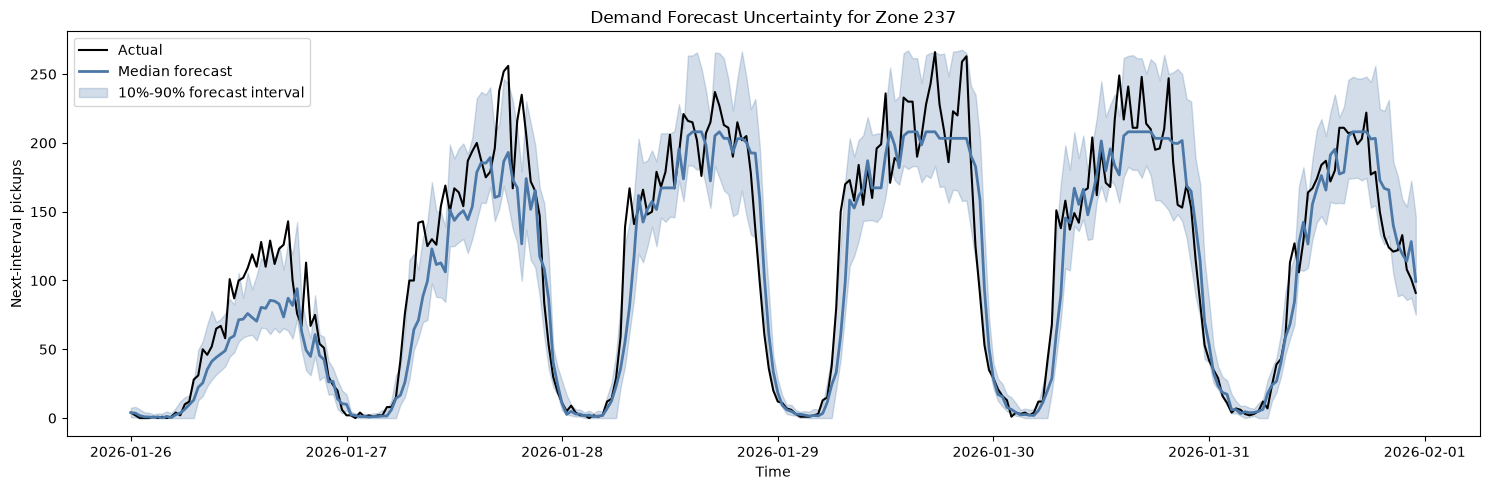

In [33]:
# Quantile forecasts for uncertain demand

try:
    from sklearn.ensemble import HistGradientBoostingRegressor
    
    quantile_models = {}
    quantiles = [0.1, 0.5, 0.9]
    
    for q in quantiles:
        model_q = HistGradientBoostingRegressor(
            loss="quantile",
            quantile=q,
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        )
        model_q.fit(X_train, y_train)
        quantile_models[q] = model_q
        test[f"pred_q{int(q * 100)}"] = np.clip(model_q.predict(X_test), 0, None)
    
    test["uncertainty_width"] = test["pred_q90"] - test["pred_q10"]
    
    quantile_summary = test[["target_next_pickup_count", "pred_q10", "pred_q50", "pred_q90", "uncertainty_width"]].describe()
    display(quantile_summary)
    
    # Visualize uncertainty for the busiest zone in the test period.
    busiest_test_zone = (
        test.groupby("PULocationID")["target_next_pickup_count"]
        .sum()
        .sort_values(ascending=False)
        .index[0]
    )
    
    zone_pred = test[test["PULocationID"] == busiest_test_zone].sort_values("time_bin")
    
    plt.figure(figsize=(15, 5))
    plt.plot(zone_pred["time_bin"], zone_pred["target_next_pickup_count"], label="Actual", color="black", linewidth=1.5)
    plt.plot(zone_pred["time_bin"], zone_pred["pred_q50"], label="Median forecast", color="#4C78A8", linewidth=2)
    plt.fill_between(
        zone_pred["time_bin"],
        zone_pred["pred_q10"],
        zone_pred["pred_q90"],
        color="#4C78A8",
        alpha=0.25,
        label="10%-90% forecast interval"
    )
    plt.title(f"Demand Forecast Uncertainty for Zone {busiest_test_zone}")
    plt.xlabel("Time")
    plt.ylabel("Next-interval pickups")
    plt.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print("Quantile forecasting skipped:", e)


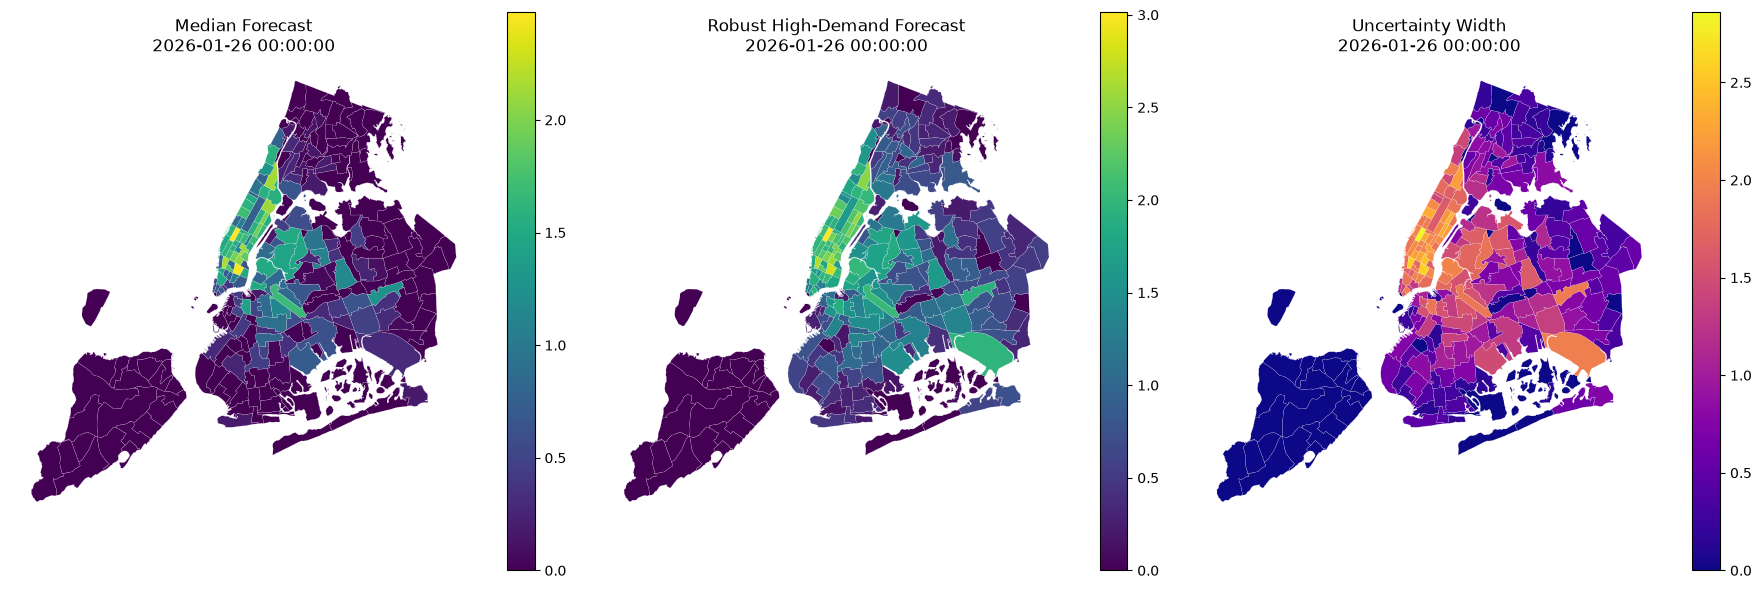

In [34]:
# Map predicted demand and uncertainty for one forecast time

if "pred_q50" in test.columns:
    forecast_time = test["time_bin"].min()
    
    forecast_map = test[test["time_bin"] == forecast_time][[
        "PULocationID", "target_next_pickup_count", "pred_q50", "pred_q90", "uncertainty_width"
    ]]
    
    plot_df = zones_base.merge(
        forecast_map,
        left_on="LocationID",
        right_on="PULocationID",
        how="left"
    )
    
    for col in ["target_next_pickup_count", "pred_q50", "pred_q90", "uncertainty_width"]:
        plot_df[col] = plot_df[col].fillna(0)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for ax, col, title in zip(
        axes,
        ["pred_q50", "pred_q90", "uncertainty_width"],
        ["Median Forecast", "Robust High-Demand Forecast", "Uncertainty Width"]
    ):
        plot_df[f"log_{col}"] = np.log1p(plot_df[col])
        plot_df.plot(
            column=f"log_{col}",
            cmap="viridis" if col != "uncertainty_width" else "plasma",
            edgecolor="white",
            linewidth=0.1,
            legend=True,
            ax=ax
        )
        ax.set_title(f"{title}\n{forecast_time}")
        ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()


In [35]:
# 2.5 Quantile uncertainty estimation diagnostics

if "test" not in globals():
    print(
        "Run the ML forecasting model cell and the quantile forecasting cell first. "
        "Those cells create test, pred_q10, pred_q50, and pred_q90."
    )
else:
    required_quantile_cols = {
        "pred_q10",
        "pred_q50",
        "pred_q90",
        "target_next_pickup_count",
    }
    missing_quantile_cols = required_quantile_cols - set(test.columns)
    
    if missing_quantile_cols:
        print(
            "Run the quantile forecasting cell first. "
            f"Missing columns in test: {sorted(missing_quantile_cols)}"
        )
    else:
        def pinball_loss(y_true, y_pred, q):
            err = y_true - y_pred
            return np.mean(np.maximum(q * err, (q - 1) * err))
        
        quantile_coverage = (
            (test["target_next_pickup_count"] >= test["pred_q10"])
            & (test["target_next_pickup_count"] <= test["pred_q90"])
        ).mean()
        
        quantile_eval = pd.Series({
            "q10_pinball_loss": pinball_loss(test["target_next_pickup_count"], test["pred_q10"], 0.1),
            "q50_pinball_loss": pinball_loss(test["target_next_pickup_count"], test["pred_q50"], 0.5),
            "q90_pinball_loss": pinball_loss(test["target_next_pickup_count"], test["pred_q90"], 0.9),
            "q10_q90_empirical_coverage": quantile_coverage,
            "mean_interval_width": (test["pred_q90"] - test["pred_q10"]).mean(),
        })
        
        display(pd.DataFrame({"Quantile uncertainty model": quantile_eval}).T)


,q10_pinball_loss,q50_pinball_loss,q90_pinball_loss,q10_q90_empirical_coverage,mean_interval_width
Quantile uncertainty model,0.441426,1.261553,0.645633,0.870413,7.341058


## Part 5. Spatial Dependence Modeling

This section adds explicit spatial dependence through zone adjacency and spatial lag features, then compares temporal-only and spatio-temporal forecasting models.


### Zone Adjacency and Spatial Lag Features

This section builds an adjacency-based spatial weights matrix and uses it to construct neighboring-zone demand features.


In [36]:
# 3.1 Zone adjacency matrix

zones_adj = zones_base.copy()
zones_adj["LocationID"] = zones_adj["LocationID"].astype(int)

if zones_adj.crs is None:
    zones_adj = zones_adj.set_crs(epsg=4326)

zones_adj = zones_adj.to_crs(epsg=2263)
zones_adj = zones_adj[["LocationID", "zone", "borough", "geometry"]].drop_duplicates("LocationID")
zones_adj = zones_adj.reset_index(drop=True)

adjacency_records = []

for i, row in zones_adj.iterrows():
    zone_id = row["LocationID"]
    touching = zones_adj[
        (zones_adj["LocationID"] != zone_id)
        & (zones_adj.geometry.touches(row.geometry))
    ]["LocationID"].tolist()
    
    # Some zones are islands or separated polygons. If no touching neighbor exists,
    # use the three nearest centroids as a practical fallback.
    if len(touching) == 0:
        distances = zones_adj.geometry.centroid.distance(row.geometry.centroid)
        nearest = (
            zones_adj.assign(distance=distances)
            .query("LocationID != @zone_id")
            .sort_values("distance")
            .head(3)["LocationID"]
            .tolist()
        )
        touching = nearest
    
    weight = 1 / len(touching) if touching else 0
    for neighbor_id in touching:
        adjacency_records.append({
            "PULocationID": zone_id,
            "neighbor_id": int(neighbor_id),
            "weight": weight
        })

adjacency_df = pd.DataFrame(adjacency_records)

print("Adjacency edges:", len(adjacency_df))
display(adjacency_df.head())


Adjacency edges: 788


,PULocationID,neighbor_id,weight
0,1,156,0.333333
1,1,187,0.333333
2,1,206,0.333333
3,2,132,1.000000
4,3,51,0.250000


In [37]:
# 3.3 Spatial lag features

neighbor_values = demand_panel[[
    "PULocationID",
    "time_bin",
    "pickup_count",
    "dropoff_count"
]].rename(columns={
    "PULocationID": "neighbor_id",
    "pickup_count": "neighbor_pickup_count",
    "dropoff_count": "neighbor_dropoff_count",
})

spatial_lag_panel = (
    adjacency_df
    .merge(neighbor_values, on="neighbor_id", how="left")
)

spatial_lag_panel["weighted_neighbor_pickup"] = (
    spatial_lag_panel["weight"] * spatial_lag_panel["neighbor_pickup_count"]
)
spatial_lag_panel["weighted_neighbor_dropoff"] = (
    spatial_lag_panel["weight"] * spatial_lag_panel["neighbor_dropoff_count"]
)

spatial_lag_panel = (
    spatial_lag_panel.groupby(["PULocationID", "time_bin"])
    .agg(
        spatial_lag_pickup=("weighted_neighbor_pickup", "sum"),
        spatial_lag_dropoff=("weighted_neighbor_dropoff", "sum")
    )
    .reset_index()
)

demand_panel = demand_panel.drop(
    columns=["spatial_lag_pickup", "spatial_lag_dropoff"],
    errors="ignore"
).merge(
    spatial_lag_panel,
    on=["PULocationID", "time_bin"],
    how="left"
)

demand_panel["spatial_lag_pickup"] = demand_panel["spatial_lag_pickup"].fillna(0)
demand_panel["spatial_lag_dropoff"] = demand_panel["spatial_lag_dropoff"].fillna(0)

# Rebuild modeling panel with spatial features.
model_panel_spatial = demand_panel.dropna(subset=[
    "pickup_lag_1",
    "pickup_lag_2",
    "pickup_lag_4",
    "pickup_lag_48",
    "target_next_pickup_count"
]).copy()

for col in ["hour_sin", "hour_cos", "weekday_sin", "weekday_cos"]:
    if col not in model_panel_spatial.columns:
        model_panel_spatial["hour_sin"] = np.sin(2 * np.pi * model_panel_spatial["hour"] / 24)
        model_panel_spatial["hour_cos"] = np.cos(2 * np.pi * model_panel_spatial["hour"] / 24)
        model_panel_spatial["weekday_sin"] = np.sin(2 * np.pi * model_panel_spatial["weekday"] / 7)
        model_panel_spatial["weekday_cos"] = np.cos(2 * np.pi * model_panel_spatial["weekday"] / 7)
        break

display(model_panel_spatial[[
    "PULocationID",
    "time_bin",
    "pickup_count",
    "spatial_lag_pickup",
    "spatial_lag_dropoff",
    "target_next_pickup_count"
]].head())


,PULocationID,time_bin,pickup_count,spatial_lag_pickup,spatial_lag_dropoff,target_next_pickup_count
48,1,2026-01-02 00:00:00,0,0.0,0.000000,0.0
49,1,2026-01-02 00:30:00,0,0.0,0.000000,0.0
50,1,2026-01-02 01:00:00,0,0.0,0.333333,0.0
51,1,2026-01-02 01:30:00,0,0.0,0.000000,0.0
52,1,2026-01-02 02:00:00,0,0.0,0.000000,0.0


,MAE,RMSE,sMAPE
Temporal-only,2.349706,6.468058,1.181715
Spatio-temporal,2.334876,6.325432,1.178780


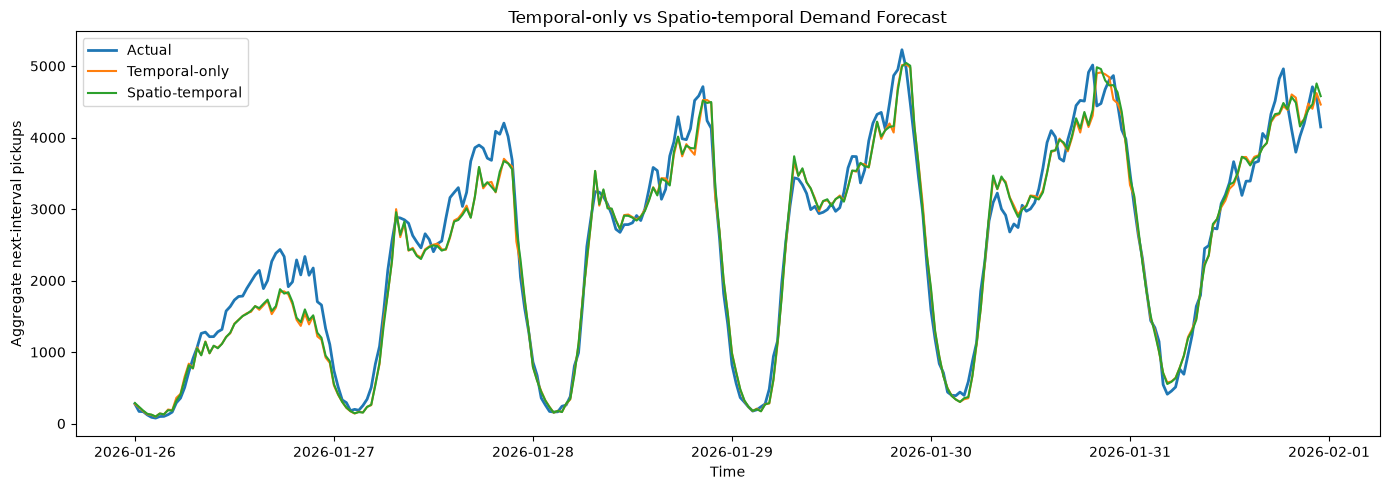

In [38]:
# 3.4 Temporal-only vs spatio-temporal model comparison

temporal_feature_cols = [
    "PULocationID",
    "hour",
    "weekday",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "weekday_sin",
    "weekday_cos",
    "pickup_lag_1",
    "pickup_lag_2",
    "pickup_lag_4",
    "pickup_lag_8",
    "pickup_lag_48",
    "dropoff_count",
    "dropoff_lag_1",
    "dropoff_lag_2",
    "rolling_mean_2h",
    "rolling_std_2h",
    "rolling_mean_6h",
    "previous_day_same_time",
]

spatiotemporal_feature_cols = temporal_feature_cols + [
    "spatial_lag_pickup",
    "spatial_lag_dropoff",
]

temporal_feature_cols = [c for c in temporal_feature_cols if c in model_panel_spatial.columns]
spatiotemporal_feature_cols = [c for c in spatiotemporal_feature_cols if c in model_panel_spatial.columns]

try:
    from sklearn.ensemble import HistGradientBoostingRegressor
    
    st_data = model_panel_spatial.dropna(subset=spatiotemporal_feature_cols + ["target_next_pickup_count"]).copy()
    cutoff_time = st_data["time_bin"].quantile(0.8)
    st_train = st_data[st_data["time_bin"] <= cutoff_time].copy()
    st_test = st_data[st_data["time_bin"] > cutoff_time].copy()
    
    y_train_st = st_train["target_next_pickup_count"]
    y_test_st = st_test["target_next_pickup_count"]
    
    temporal_model = HistGradientBoostingRegressor(
        loss="poisson",
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
    temporal_model.fit(st_train[temporal_feature_cols], y_train_st)
    
    st_model = HistGradientBoostingRegressor(
        loss="poisson",
        max_iter=250,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=42
    )
    st_model.fit(st_train[spatiotemporal_feature_cols], y_train_st)
    
    st_test["temporal_pred"] = np.clip(temporal_model.predict(st_test[temporal_feature_cols]), 0, None)
    st_test["spatiotemporal_pred"] = np.clip(st_model.predict(st_test[spatiotemporal_feature_cols]), 0, None)
    
    comparison = pd.DataFrame({
        "Temporal-only": demand_metrics(y_test_st, st_test["temporal_pred"]),
        "Spatio-temporal": demand_metrics(y_test_st, st_test["spatiotemporal_pred"]),
    }).T
    
    display(comparison)
    
    aggregate_compare = (
        st_test.groupby("time_bin")
        .agg(
            actual=("target_next_pickup_count", "sum"),
            temporal_pred=("temporal_pred", "sum"),
            spatiotemporal_pred=("spatiotemporal_pred", "sum")
        )
        .reset_index()
    )
    
    plt.figure(figsize=(14, 5))
    plt.plot(aggregate_compare["time_bin"], aggregate_compare["actual"], label="Actual", linewidth=2)
    plt.plot(aggregate_compare["time_bin"], aggregate_compare["temporal_pred"], label="Temporal-only", linewidth=1.5)
    plt.plot(aggregate_compare["time_bin"], aggregate_compare["spatiotemporal_pred"], label="Spatio-temporal", linewidth=1.5)
    plt.title("Temporal-only vs Spatio-temporal Demand Forecast")
    plt.xlabel("Time")
    plt.ylabel("Aggregate next-interval pickups")
    plt.legend()
    plt.tight_layout()
    plt.show()

except ImportError:
    print("scikit-learn is not installed. Install it with: pip install scikit-learn")


# Appendix

The cells below are kept for reference but are not part of the main demand-side project narrative.

- Appendix A: preliminary Negative Binomial baseline from an earlier modeling iteration
- Appendix B: supply-demand allocation prototypes

Because this dataset does not include real-time taxi availability, the allocation cells should be treated as optional prototypes or future work rather than main results.


## Appendix A. Preliminary Negative Binomial Baseline


### Earlier Baseline NB Model

This earlier Negative Binomial baseline is retained for reference. The main project narrative uses the later Poisson/NHPP -> overdispersion -> NB extension pipeline.


In [28]:
# Negative Binomial baseline

try:
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    
    # Fit on the busiest zones first to keep the notebook responsive.
    nb_top_zones = (
        model_panel.groupby("PULocationID")["target_next_pickup_count"]
        .sum()
        .sort_values(ascending=False)
        .head(60)
        .index
    )
    
    nb_data = model_panel[model_panel["PULocationID"].isin(nb_top_zones)].copy()
    nb_data["PULocationID"] = nb_data["PULocationID"].astype("category")
    nb_data["hour"] = nb_data["hour"].astype("category")
    nb_data["weekday"] = nb_data["weekday"].astype("category")
    
    cutoff_time = nb_data["time_bin"].quantile(0.8)
    nb_train = nb_data[nb_data["time_bin"] <= cutoff_time].copy()
    nb_test = nb_data[nb_data["time_bin"] > cutoff_time].copy()
    
    nb_formula = (
        "target_next_pickup_count ~ C(PULocationID) + C(hour) + C(weekday) + is_weekend "
        "+ pickup_lag_1 + pickup_lag_2 + pickup_lag_4 + pickup_lag_48 "
        "+ dropoff_lag_1 + rolling_mean_2h + rolling_std_2h + previous_day_same_time"
    )
    
    poisson_model = smf.glm(
        formula=nb_formula,
        data=nb_train,
        family=sm.families.Poisson()
    ).fit()
    
    nb_model = smf.glm(
        formula=nb_formula,
        data=nb_train,
        family=sm.families.NegativeBinomial()
    ).fit()
    
    nb_test["poisson_pred"] = poisson_model.predict(nb_test)
    nb_test["nb_pred"] = nb_model.predict(nb_test)
    
    def regression_metrics(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        mae = np.mean(np.abs(y_true - y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))
        return pd.Series({"MAE": mae, "RMSE": rmse, "sMAPE": smape})
    
    nb_results = pd.DataFrame({
        "Poisson": regression_metrics(nb_test["target_next_pickup_count"], nb_test["poisson_pred"]),
        "Negative Binomial": regression_metrics(nb_test["target_next_pickup_count"], nb_test["nb_pred"])
    }).T
    
    display(nb_results)
    print("Poisson AIC:", poisson_model.aic)
    print("Negative Binomial AIC:", nb_model.aic)

except ImportError:
    print("statsmodels is not installed. Install it with: pip install statsmodels")


C:\Users\ZZKT1\anaconda3\envs\new_nyc-taxi-or\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


,MAE,RMSE,sMAPE
Poisson,11.040126,18.571710,0.500864
Negative Binomial,17.370763,74.447083,0.481799


Poisson AIC: 785214.966926537
Negative Binomial AIC: 555380.0317034496


## Appendix B. Supply-Demand Optimization Prototypes


### Simple Resource Allocation Prototype

This prototype is retained as future-work material because real-time taxi supply is not available in the current trip records.


,served_demand,unmet_demand,idle_taxis,service_rate
median_policy,513971.405907,196978.594093,27854.773998,0.722936
robust_policy,500200.317234,210749.682766,41625.862670,0.703566


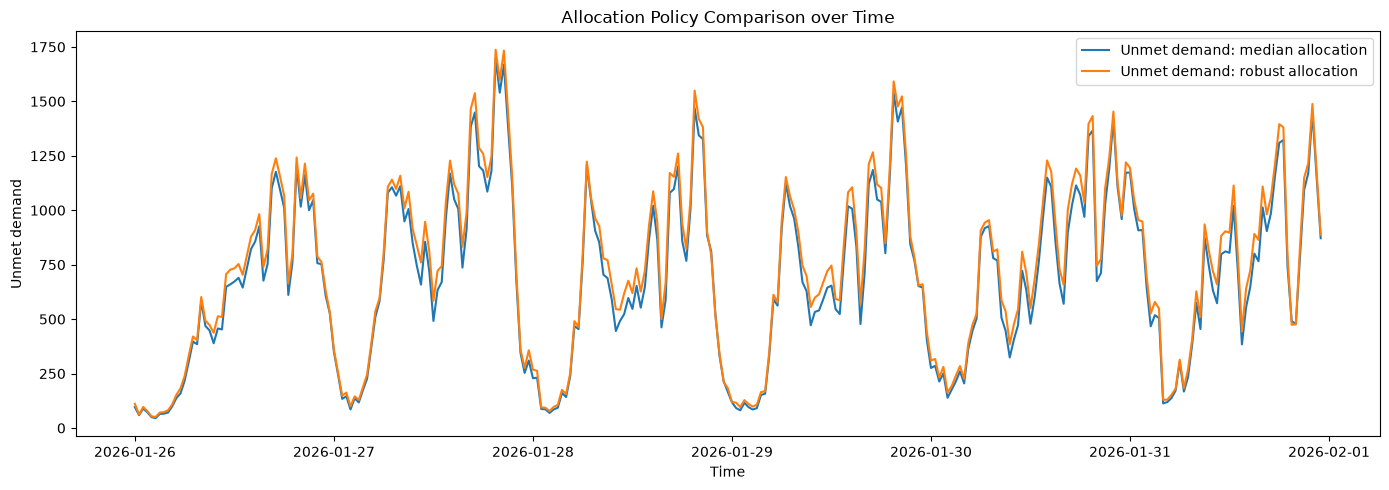

In [63]:
# Allocation under limited taxi resources

# This version avoids groupby.apply because some pandas versions remove the
# grouping column from the returned DataFrame, which can cause KeyError: 'time_bin'.

if {"pred_q50", "pred_q90"}.issubset(test.columns):
    allocation_eval = test.copy()
    
    # Example assumption: available taxis cover 85% of predicted median demand
    # in each time bin. You can replace this with a real fleet constraint later.
    service_fraction = 0.85
    
    # Total available taxis by time interval.
    allocation_eval["time_budget"] = (
        service_fraction
        * allocation_eval.groupby("time_bin")["pred_q50"].transform("sum")
    )
    
    # Forecast sums by time interval. These are used as allocation weights.
    allocation_eval["sum_pred_q50"] = allocation_eval.groupby("time_bin")["pred_q50"].transform("sum")
    allocation_eval["sum_pred_q90"] = allocation_eval.groupby("time_bin")["pred_q90"].transform("sum")
    
    # Median-demand allocation:
    # zones with higher median predicted demand receive more taxis.
    allocation_eval["alloc_median"] = np.where(
        allocation_eval["sum_pred_q50"] > 0,
        allocation_eval["time_budget"] * allocation_eval["pred_q50"] / allocation_eval["sum_pred_q50"],
        0
    )
    
    # Robust allocation:
    # zones with higher high-quantile demand receive more taxis.
    allocation_eval["alloc_robust"] = np.where(
        allocation_eval["sum_pred_q90"] > 0,
        allocation_eval["time_budget"] * allocation_eval["pred_q90"] / allocation_eval["sum_pred_q90"],
        0
    )
    
    for policy in ["median", "robust"]:
        alloc_col = f"alloc_{policy}"
        allocation_eval[f"served_{policy}"] = np.minimum(
            allocation_eval[alloc_col],
            allocation_eval["target_next_pickup_count"]
        )
        allocation_eval[f"unmet_{policy}"] = np.maximum(
            allocation_eval["target_next_pickup_count"] - allocation_eval[alloc_col],
            0
        )
        allocation_eval[f"idle_{policy}"] = np.maximum(
            allocation_eval[alloc_col] - allocation_eval["target_next_pickup_count"],
            0
        )
    
    policy_summary = pd.DataFrame({
        "median_policy": {
            "served_demand": allocation_eval["served_median"].sum(),
            "unmet_demand": allocation_eval["unmet_median"].sum(),
            "idle_taxis": allocation_eval["idle_median"].sum(),
            "service_rate": allocation_eval["served_median"].sum() / allocation_eval["target_next_pickup_count"].sum()
        },
        "robust_policy": {
            "served_demand": allocation_eval["served_robust"].sum(),
            "unmet_demand": allocation_eval["unmet_robust"].sum(),
            "idle_taxis": allocation_eval["idle_robust"].sum(),
            "service_rate": allocation_eval["served_robust"].sum() / allocation_eval["target_next_pickup_count"].sum()
        }
    }).T
    
    display(policy_summary)
    
    service_ts = (
        allocation_eval.groupby("time_bin")
        .agg(
            actual_demand=("target_next_pickup_count", "sum"),
            total_budget=("time_budget", "first"),
            unmet_median=("unmet_median", "sum"),
            unmet_robust=("unmet_robust", "sum"),
            idle_median=("idle_median", "sum"),
            idle_robust=("idle_robust", "sum")
        )
        .reset_index()
    )
    
    plt.figure(figsize=(14, 5))
    plt.plot(service_ts["time_bin"], service_ts["unmet_median"], label="Unmet demand: median allocation")
    plt.plot(service_ts["time_bin"], service_ts["unmet_robust"], label="Unmet demand: robust allocation")
    plt.title("Allocation Policy Comparison over Time")
    plt.xlabel("Time")
    plt.ylabel("Unmet demand")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Run the quantile forecasting cell first so test contains pred_q50 and pred_q90.")


### Linear Programming and Robust Allocation Prototype

These cells explore possible supply-demand optimization formulations, but they are not part of the current demand-side main results.


In [ ]:
# 4.1 Supply assumption and helper functions

if {"pred_q50", "pred_q90"}.issubset(test.columns):
    decision_data = test.copy().reset_index(drop=True)
    decision_data["row_id"] = np.arange(len(decision_data))
    
    # Assumption: the total available fleet in each interval covers this fraction
    # of predicted median demand. This can be replaced by real fleet availability.
    service_fraction = 0.85
    
    decision_data["time_budget"] = (
        service_fraction
        * decision_data.groupby("time_bin")["pred_q50"].transform("sum")
    )
    
    # Dropoffs proxy local available supply. Scale the proxy to match the time budget.
    dropoff_sum = decision_data.groupby("time_bin")["dropoff_count"].transform("sum")
    zone_count = decision_data.groupby("time_bin")["PULocationID"].transform("count")
    
    decision_data["supply_proxy_scaled"] = np.where(
        dropoff_sum > 0,
        decision_data["time_budget"] * decision_data["dropoff_count"] / dropoff_sum,
        decision_data["time_budget"] / zone_count
    )
    
    def evaluate_allocation_policy(data, alloc_col, actual_col="target_next_pickup_count"):
        served = np.minimum(data[alloc_col], data[actual_col])
        unmet = np.maximum(data[actual_col] - data[alloc_col], 0)
        idle = np.maximum(data[alloc_col] - data[actual_col], 0)
        relocation = np.abs(data[alloc_col] - data["supply_proxy_scaled"])
        
        return pd.Series({
            "service_rate": served.sum() / data[actual_col].sum(),
            "served_demand": served.sum(),
            "unmet_demand": unmet.sum(),
            "idle_vehicles": idle.sum(),
            "relocation_cost_proxy": relocation.sum(),
        })
    
    display(decision_data[[
        "time_bin",
        "PULocationID",
        "pred_q50",
        "pred_q90",
        "target_next_pickup_count",
        "time_budget",
        "supply_proxy_scaled"
    ]].head())
else:
    print("Run the quantile forecasting cell first so test contains pred_q50 and pred_q90.")


In [ ]:
# 4.2 Proportional allocation baseline

if "decision_data" in globals():
    decision_data["sum_pred_q50"] = decision_data.groupby("time_bin")["pred_q50"].transform("sum")
    decision_data["sum_pred_q90"] = decision_data.groupby("time_bin")["pred_q90"].transform("sum")
    
    decision_data["alloc_prop_median"] = np.where(
        decision_data["sum_pred_q50"] > 0,
        decision_data["time_budget"] * decision_data["pred_q50"] / decision_data["sum_pred_q50"],
        0
    )
    
    decision_data["alloc_prop_robust"] = np.where(
        decision_data["sum_pred_q90"] > 0,
        decision_data["time_budget"] * decision_data["pred_q90"] / decision_data["sum_pred_q90"],
        0
    )
    
    prop_eval = pd.DataFrame({
        "proportional_median_q50": evaluate_allocation_policy(decision_data, "alloc_prop_median"),
        "proportional_robust_q90": evaluate_allocation_policy(decision_data, "alloc_prop_robust"),
    }).T
    
    display(prop_eval)


In [ ]:
# 4.3 Linear programming optimization
# 4.4 Robust optimization using demand uncertainty

try:
    from scipy.optimize import linprog
    
    def solve_allocation_lp(group, demand_col, wait_cost=1.0, idle_cost=0.15, relocation_cost=0.05):
        group = group.copy()
        n = len(group)
        demand = group[demand_col].to_numpy(dtype=float)
        supply = group["supply_proxy_scaled"].to_numpy(dtype=float)
        budget = float(group["time_budget"].iloc[0])
        
        # Variables: x, unmet, idle, relocation_plus, relocation_minus.
        c = np.concatenate([
            np.zeros(n),
            wait_cost * np.ones(n),
            idle_cost * np.ones(n),
            relocation_cost * np.ones(n),
            relocation_cost * np.ones(n),
        ])
        
        A_eq = []
        b_eq = []
        
        # x + unmet - idle = demand
        for i in range(n):
            row = np.zeros(5 * n)
            row[i] = 1
            row[n + i] = 1
            row[2 * n + i] = -1
            A_eq.append(row)
            b_eq.append(demand[i])
        
        # x - relocation_plus + relocation_minus = supply_proxy_scaled
        for i in range(n):
            row = np.zeros(5 * n)
            row[i] = 1
            row[3 * n + i] = -1
            row[4 * n + i] = 1
            A_eq.append(row)
            b_eq.append(supply[i])
        
        A_ub = np.zeros((1, 5 * n))
        A_ub[0, :n] = 1
        b_ub = np.array([budget])
        
        bounds = [(0, None)] * (5 * n)
        
        result = linprog(
            c,
            A_ub=A_ub,
            b_ub=b_ub,
            A_eq=np.vstack(A_eq),
            b_eq=np.array(b_eq),
            bounds=bounds,
            method="highs"
        )
        
        if not result.success:
            group[f"alloc_lp_{demand_col}"] = group["time_budget"] / n
            group[f"lp_status_{demand_col}"] = result.message
        else:
            group[f"alloc_lp_{demand_col}"] = result.x[:n]
            group[f"lp_status_{demand_col}"] = "optimal"
        
        return group[["row_id", f"alloc_lp_{demand_col}", f"lp_status_{demand_col}"]]
    
    # Use all test time bins by default. If it runs slowly, set MAX_OPT_TIME_BINS to a smaller number.
    MAX_OPT_TIME_BINS = None
    
    opt_source = decision_data.copy()
    if MAX_OPT_TIME_BINS is not None:
        selected_times = opt_source["time_bin"].drop_duplicates().sort_values().head(MAX_OPT_TIME_BINS)
        opt_source = opt_source[opt_source["time_bin"].isin(selected_times)].copy()
    
    lp_median_parts = []
    lp_robust_parts = []
    
    for _, group in opt_source.groupby("time_bin"):
        lp_median_parts.append(solve_allocation_lp(group, "pred_q50"))
        lp_robust_parts.append(solve_allocation_lp(group, "pred_q90"))
    
    lp_median = pd.concat(lp_median_parts, ignore_index=True)
    lp_robust = pd.concat(lp_robust_parts, ignore_index=True)
    
    decision_data = (
        decision_data
        .merge(lp_median, on="row_id", how="left")
        .merge(lp_robust, on="row_id", how="left")
    )
    
    decision_data["alloc_lp_pred_q50"] = decision_data["alloc_lp_pred_q50"].fillna(0)
    decision_data["alloc_lp_pred_q90"] = decision_data["alloc_lp_pred_q90"].fillna(0)
    
    lp_eval = pd.DataFrame({
        "lp_median_q50": evaluate_allocation_policy(decision_data, "alloc_lp_pred_q50"),
        "lp_robust_q90": evaluate_allocation_policy(decision_data, "alloc_lp_pred_q90"),
    }).T
    
    display(lp_eval)

except ImportError:
    print("scipy is not installed. Install it with: pip install scipy")
except Exception as e:
    print("Linear programming optimization skipped:", e)


In [ ]:
# 4.5 Evaluation: compare proportional and LP allocation policies

if "decision_data" in globals():
    policy_cols = [
        col for col in [
            "alloc_prop_median",
            "alloc_prop_robust",
            "alloc_lp_pred_q50",
            "alloc_lp_pred_q90",
        ]
        if col in decision_data.columns
    ]
    
    evaluation_table = pd.DataFrame({
        col: evaluate_allocation_policy(decision_data, col)
        for col in policy_cols
    }).T
    
    display(evaluation_table.sort_values("unmet_demand"))
    
    eval_ts = (
        decision_data.groupby("time_bin")
        .agg(
            actual_demand=("target_next_pickup_count", "sum"),
            prop_median_unmet=("alloc_prop_median", lambda x: np.nan),
        )
        .reset_index()
    )
    
    plt.figure(figsize=(14, 5))
    for col in policy_cols:
        unmet_by_time = (
            decision_data.assign(unmet=lambda x: np.maximum(x["target_next_pickup_count"] - x[col], 0))
            .groupby("time_bin")["unmet"]
            .sum()
            .reset_index()
        )
        plt.plot(unmet_by_time["time_bin"], unmet_by_time["unmet"], label=col)
    
    plt.title("Unmet Demand by Allocation Policy")
    plt.xlabel("Time")
    plt.ylabel("Unmet demand")
    plt.legend()
    plt.tight_layout()
    plt.show()
